In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (2).csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test (2).csv


In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [ ]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (1530, 35)
Test Shape: (28913, 35)


In [ ]:
train.head()

,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,...,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Application Type,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Loan Status
0,65087372,10000,32236,12329.36286,59.0,BAT2522922,11.135007,B,C4,MORTGAGE,...,2.498291,0.793724,0.0,INDIVIDUAL,49.0,0.0,31.0,311301.0,6619.0,0.0
1,1450153,3609,11940,12191.99692,59.0,BAT1586599,12.237563,C,D3,RENT,...,2.377215,0.974821,0.0,INDIVIDUAL,109.0,0.0,53.0,182610.0,20885.0,0.0
2,1969101,28276,9311,21603.22455,59.0,BAT2136391,12.545884,F,D4,MORTGAGE,...,4.316277,1.020075,0.0,INDIVIDUAL,66.0,0.0,34.0,89801.0,26155.0,0.0
3,6651430,11170,6954,17877.15585,59.0,BAT2428731,16.731201,C,C3,MORTGAGE,...,0.107020,0.749971,0.0,INDIVIDUAL,39.0,0.0,40.0,9189.0,60214.0,0.0
4,14354669,16890,13226,13539.92667,59.0,BAT5341619,15.008300,C,D4,MORTGAGE,...,1294.818751,0.368953,0.0,INDIVIDUAL,18.0,0.0,430.0,126029.0,22579.0,0.0


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            1530 non-null   int64  
 1   Loan Amount                   1530 non-null   int64  
 2   Funded Amount                 1530 non-null   int64  
 3   Funded Amount Investor        1529 non-null   float64
 4   Term                          1529 non-null   float64
 5   Batch Enrolled                1529 non-null   object 
 6   Interest Rate                 1529 non-null   float64
 7   Grade                         1529 non-null   object 
 8   Sub Grade                     1529 non-null   object 
 9   Employment Duration           1529 non-null   object 
 10  Home Ownership                1529 non-null   float64
 11  Verification Status           1529 non-null   object 
 12  Payment Plan                  1529 non-null   object 
 13  Loa

In [ ]:
train.isnull().sum()

,0
ID,0
Loan Amount,0
Funded Amount,0
Funded Amount Investor,1
Term,1
Batch Enrolled,1
Interest Rate,1
Grade,1
Sub Grade,1
Employment Duration,1


In [ ]:
print(train.columns.tolist())

['ID', 'Loan Amount', 'Funded Amount', 'Funded Amount Investor', 'Term', 'Batch Enrolled', 'Interest Rate', 'Grade', 'Sub Grade', 'Employment Duration', 'Home Ownership', 'Verification Status', 'Payment Plan', 'Loan Title', 'Debit to Income', 'Delinquency - two years', 'Inquires - six months', 'Open Account', 'Public Record', 'Revolving Balance', 'Revolving Utilities', 'Total Accounts', 'Initial List Status', 'Total Received Interest', 'Total Received Late Fee', 'Recoveries', 'Collection Recovery Fee', 'Collection 12 months Medical', 'Application Type', 'Last week Pay', 'Accounts Delinquent', 'Total Collection Amount', 'Total Current Balance', 'Total Revolving Credit Limit', 'Loan Status']


In [ ]:
train.describe()

,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Interest Rate,Home Ownership,Debit to Income,Delinquency - two years,Inquires - six months,...,Total Received Late Fee,Recoveries,Collection Recovery Fee,Collection 12 months Medical,Last week Pay,Accounts Delinquent,Total Collection Amount,Total Current Balance,Total Revolving Credit Limit,Loan Status
count,1.530000e+03,1530.000000,1530.000000,1529.000000,1529.00000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,...,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.0,1529.000000,1529.000000,1529.000000,1529.000000
mean,2.515309e+07,17199.342484,15718.981046,14510.477165,58.22760,12.080704,81967.521176,23.252435,0.317855,0.153695,...,1.260993,49.932795,1.149679,0.013080,70.424460,0.0,148.604317,160737.765206,24545.732505,0.096795
std,2.074778e+07,8451.974178,8237.048064,6795.040291,3.12719,3.747298,46687.670646,8.594004,0.830348,0.488668,...,5.497750,309.297108,3.365895,0.113656,43.234139,0.0,756.890686,138040.567716,21885.951291,0.295776
min,1.302632e+06,1149.000000,2757.000000,1980.938852,36.00000,5.335268,17219.909980,3.708711,0.000000,0.000000,...,0.000028,0.001575,0.002458,0.000000,0.000000,0.0,1.000000,1170.000000,1000.000000,0.000000
25%,6.596208e+06,10617.250000,9077.750000,9725.471480,58.00000,9.412732,52206.404080,16.687919,0.000000,0.000000,...,0.021169,1.508671,0.492545,0.000000,34.000000,0.0,24.000000,55814.000000,8843.000000,0.000000
50%,1.730404e+07,16104.500000,12630.000000,12658.231660,59.00000,11.794936,69743.557030,22.536191,0.000000,0.000000,...,0.042557,3.212892,0.799445,0.000000,67.000000,0.0,36.000000,124016.000000,17876.000000,0.000000
75%,4.250388e+07,22417.250000,21842.250000,18550.084900,59.00000,14.501061,95380.569290,30.218859,0.000000,0.000000,...,0.072470,5.311784,1.085548,0.000000,104.000000,0.0,47.000000,225169.000000,34786.000000,0.000000
max,7.153761e+07,34985.000000,34958.000000,34938.823270,59.00000,26.920449,386152.945900,39.525458,7.000000,4.000000,...,39.064268,3618.803694,41.823678,1.000000,161.000000,0.0,13913.000000,978345.000000,158957.000000,1.000000


In [ ]:
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:")
print(numerical_cols)

print("\n")

categorical_cols = train.select_dtypes(include=['object']).columns
print("Categorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['ID', 'Loan Amount', 'Funded Amount', 'Funded Amount Investor', 'Term',
       'Interest Rate', 'Home Ownership', 'Debit to Income',
       'Delinquency - two years', 'Inquires - six months', 'Open Account',
       'Public Record', 'Revolving Balance', 'Revolving Utilities',
       'Total Accounts', 'Total Received Interest', 'Total Received Late Fee',
       'Recoveries', 'Collection Recovery Fee', 'Collection 12 months Medical',
       'Last week Pay', 'Accounts Delinquent', 'Total Collection Amount',
       'Total Current Balance', 'Total Revolving Credit Limit', 'Loan Status'],
      dtype='object')


Categorical Columns:
Index(['Batch Enrolled', 'Grade', 'Sub Grade', 'Employment Duration',
       'Verification Status', 'Payment Plan', 'Loan Title',
       'Initial List Status', 'Application Type'],
      dtype='object')


In [ ]:
for col in numerical_cols:
    train[col].fillna(train[col].median(), inplace=True)
    test[col].fillna(test[col].median(), inplace=True)

/tmp/ipykernel_1817/1940958371.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].median(), inplace=True)
/tmp/ipykernel_1817/1940958371.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [ ]:
for col in categorical_cols:
    train[col].fillna(train[col].mode()[0], inplace=True)
    test[col].fillna(test[col].mode()[0], inplace=True)

/tmp/ipykernel_1817/3462639137.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].mode()[0], inplace=True)
/tmp/ipykernel_1817/3462639137.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [ ]:
train.isnull().sum()

,0
ID,0
Loan Amount,0
Funded Amount,0
Funded Amount Investor,0
Term,0
Batch Enrolled,0
Interest Rate,0
Grade,0
Sub Grade,0
Employment Duration,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = train.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()

    combined = pd.concat([train[col], test[col]], axis=0).astype(str)

    le.fit(combined)

    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

print("Encoding completed successfully!")

Encoding completed successfully!


In [ ]:
print(train.columns.tolist())

['ID', 'Loan Amount', 'Funded Amount', 'Funded Amount Investor', 'Term', 'Batch Enrolled', 'Interest Rate', 'Grade', 'Sub Grade', 'Employment Duration', 'Home Ownership', 'Verification Status', 'Payment Plan', 'Loan Title', 'Debit to Income', 'Delinquency - two years', 'Inquires - six months', 'Open Account', 'Public Record', 'Revolving Balance', 'Revolving Utilities', 'Total Accounts', 'Initial List Status', 'Total Received Interest', 'Total Received Late Fee', 'Recoveries', 'Collection Recovery Fee', 'Collection 12 months Medical', 'Application Type', 'Last week Pay', 'Accounts Delinquent', 'Total Collection Amount', 'Total Current Balance', 'Total Revolving Credit Limit', 'Loan Status']


In [ ]:
X = train.drop(['Loan Status', 'ID'], axis=1)
y = train['Loan Status']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1530, 33)
Target Shape: (1530,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_valid.shape)

(1224, 33)
(306, 33)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = lr.predict(X_valid)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :", accuracy_score(y_valid, y_pred))
print("Precision:", precision_score(y_valid, y_pred))
print("Recall   :", recall_score(y_valid, y_pred))
print("F1 Score :", f1_score(y_valid, y_pred))

Accuracy : 0.9019607843137255
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


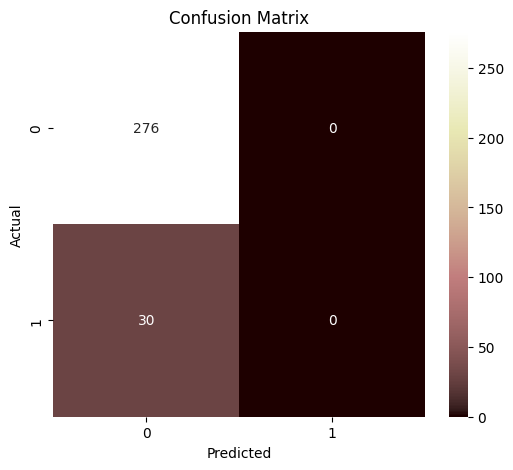

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='pink')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95       276
         1.0       0.00      0.00      0.00        30

    accuracy                           0.90       306
   macro avg       0.45      0.50      0.47       306
weighted avg       0.81      0.90      0.86       306



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import roc_auc_score

probabilities = model.predict_proba(X_valid)[:,1]

roc = roc_auc_score(y_valid, probabilities)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.49619565217391304


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("All models trained successfully!")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


All models trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

results = []

for name, model in models.items():

    pred = model.predict(X_valid)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_valid)[:,1]
        roc = roc_auc_score(y_valid, prob)
    else:
        roc = "N/A"

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_valid, pred),
        "Precision": precision_score(y_valid, pred),
        "Recall": recall_score(y_valid, pred),
        "F1 Score": f1_score(y_valid, pred),
        "ROC-AUC": roc
    })

results = pd.DataFrame(results)

results

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.901961,0.000000,0.000000,0.000000,0.317512
1,Decision Tree,0.813725,0.034483,0.033333,0.033898,0.465942
2,Random Forest,0.901961,0.000000,0.000000,0.000000,0.496196


In [ ]:
results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.901961,0.000000,0.000000,0.000000,0.317512
2,Random Forest,0.901961,0.000000,0.000000,0.000000,0.496196
1,Decision Tree,0.813725,0.034483,0.033333,0.033898,0.465942


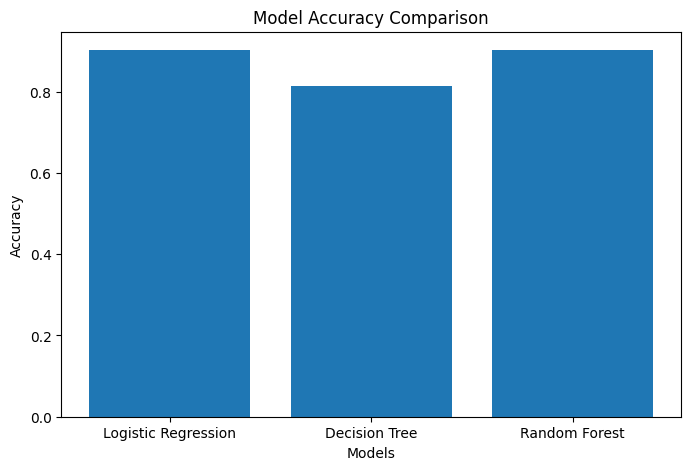

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_valid)

    y_prob = model.predict_proba(X_valid)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Precision": precision_score(y_valid, y_pred),
        "Recall": recall_score(y_valid, y_pred),
        "F1 Score": f1_score(y_valid, y_pred),
        "ROC-AUC": roc_auc_score(y_valid, y_prob)
    })

results_df = pd.DataFrame(results)

display(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.901961,0.000000,0.000000,0.000000,0.317512
1,Decision Tree,0.813725,0.034483,0.033333,0.033898,0.465942
2,Random Forest,0.901961,0.000000,0.000000,0.000000,0.496196


In [ ]:
test_features = test.drop(['ID', 'Loan Status'], axis=1)

predictions = rf.predict(test_features)

print(predictions[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
